<a href="https://colab.research.google.com/github/sudip328/Random-Forest-Cs2GeX6-/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)

df

,Compound,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy,Band_gap
0,Cs2GeF6,9.23,786.86,1.14,0.398,-4.78,5.910
1,Cs2GeCl6,10.59,1187.00,1.05,0.293,-3.38,2.260
2,Cs2GeBr6,11.09,1365.11,1.03,0.271,-2.72,1.016
3,Cs2GeI6,11.70,1601.50,1.00,0.241,-1.03,0.000


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(4, 7)

Column names:
['Compound', 'Lattice_parameter', 'Volume', 'Tolerance_factor', 'Octahedral_factor', 'Formation_energy', 'Band_gap']

Missing values:
Compound             0
Lattice_parameter    0
Volume               0
Tolerance_factor     0
Octahedral_factor    0
Formation_energy     0
Band_gap             0
dtype: int64


In [4]:
feature_columns = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

target_column = "Band_gap"

X = df[feature_columns]
y = df[target_column]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
   Lattice_parameter   Volume  Tolerance_factor  Octahedral_factor  \
0               9.23   786.86              1.14              0.398   
1              10.59  1187.00              1.05              0.293   
2              11.09  1365.11              1.03              0.271   
3              11.70  1601.50              1.00              0.241   

   Formation_energy  
0             -4.78  
1             -3.38  
2             -2.72  
3             -1.03  

Target (y):
0    5.910
1    2.260
2    1.016
3    0.000
Name: Band_gap, dtype: float64


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

print(rf_model)

RandomForestRegressor(n_estimators=500, random_state=42)


In [6]:
rf_model.fit(X, y)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [7]:
y_pred = rf_model.predict(X)

results = pd.DataFrame({
    "Compound": df["Compound"],
    "Actual_Band_Gap": y,
    "Predicted_Band_Gap": y_pred
})

results

,Compound,Actual_Band_Gap,Predicted_Band_Gap
0,Cs2GeF6,5.910,4.828872
1,Cs2GeCl6,2.260,1.940812
2,Cs2GeBr6,1.016,1.329368
3,Cs2GeI6,0.000,0.487472


In [8]:
train_rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

print(f"Training RMSE = {train_rmse:.4f} eV")

Training RMSE = 0.6337 eV


In [9]:
train_mae = mean_absolute_error(y, y_pred)
train_r2 = r2_score(y, y_pred)

print(f"Training RMSE = {train_rmse:.4f} eV")
print(f"Training MAE  = {train_mae:.4f} eV")
print(f"Training R²   = {train_r2:.4f}")

Training RMSE = 0.6337 eV
Training MAE  = 0.5503 eV
Training R²   = 0.9196


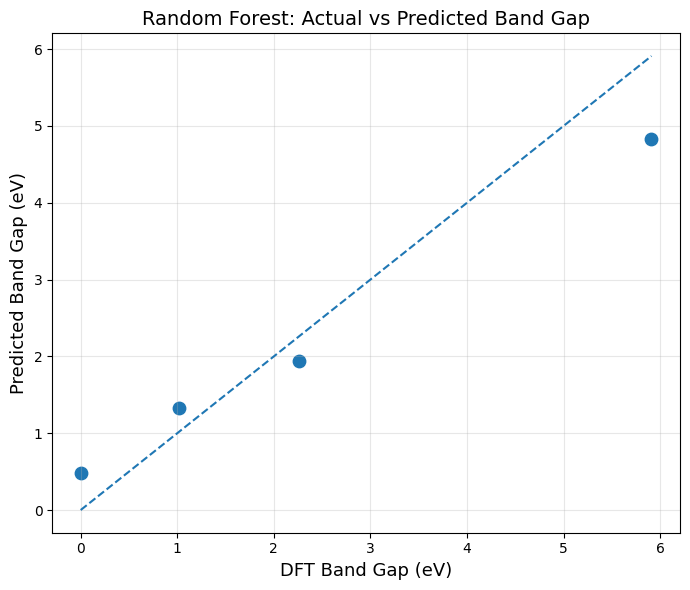

In [10]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y,
    y_pred,
    s=80
)

# Perfect prediction line
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("DFT Band Gap (eV)", fontsize=13)
plt.ylabel("Predicted Band Gap (eV)", fontsize=13)

plt.title(
    "Random Forest: Actual vs Predicted Band Gap",
    fontsize=14
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    # Training data
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Create a new Random Forest for each fold
    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict the left-out compound
    prediction = model.predict(X_test)

    loo_predictions.append(prediction[0])
    loo_actual.append(y_test.iloc[0])
    loo_compounds.append(
        df["Compound"].iloc[test_index[0]]
    )

loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

# Calculate LOOCV metrics after predictions are available
loo_rmse = np.sqrt(
    mean_squared_error(loo_actual, loo_predictions)
)
loo_mae = mean_absolute_error(loo_actual, loo_predictions)
loo_r2 = r2_score(loo_actual, loo_predictions)

loo_results

,Compound,Actual_Band_Gap,LOOCV_Predicted_Band_Gap
0,Cs2GeF6,5.910,1.890240
1,Cs2GeCl6,2.260,1.540260
2,Cs2GeBr6,1.016,1.772160
3,Cs2GeI6,0.000,1.518112


In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R²"
    ],

    "Training": [
        train_rmse,
        train_mae,
        train_r2
    ],

    "LOOCV": [
        loo_rmse,
        loo_mae,
        loo_r2
    ]
})

comparison

NameError: name 'loo_rmse' is not defined

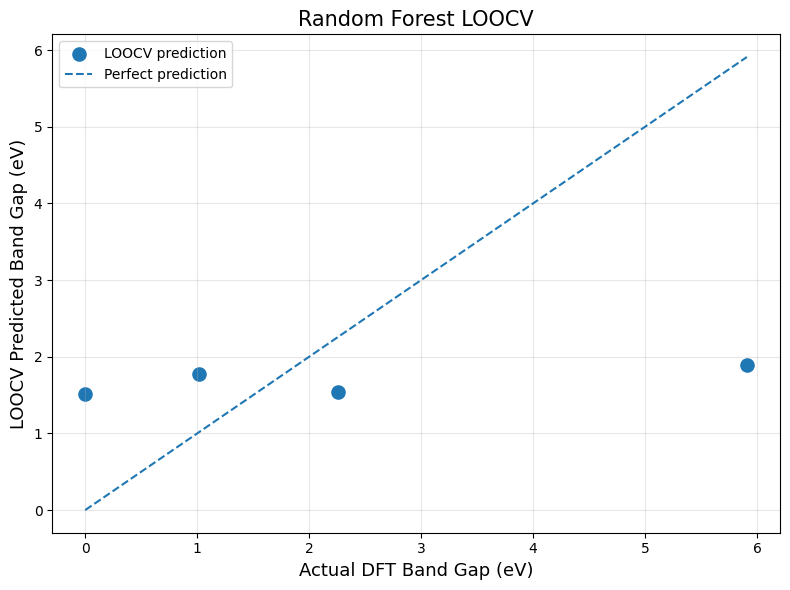

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    loo_actual,
    loo_predictions,
    s=90,
    label="LOOCV prediction"
)

min_value = min(
    min(loo_actual),
    min(loo_predictions)
)

max_value = max(
    max(loo_actual),
    max(loo_predictions)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual DFT Band Gap (eV)", fontsize=13)
plt.ylabel("LOOCV Predicted Band Gap (eV)", fontsize=13)

plt.title(
    "Random Forest LOOCV",
    fontsize=15
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
<!-- This cell is redundant with cell 9TcV9kNcewmg and has been disabled. -->

===== OVERFITTING ANALYSIS =====
Training RMSE : 0.6337 eV


NameError: name 'loo_rmse' is not defined

In [15]:
print("===== OVERFITTING ANALYSIS ====")

print(f"Training RMSE : {train_rmse:.4f} eV")
print(f"LOOCV RMSE    : {loo_rmse:.4f} eV")

print()

print(f"Training R²   : {train_r2:.4f}")
print(f"LOOCV R²      : {loo_r2:.4f}")

print()

rmse_difference = loo_rmse - train_rmse

print(
    f"RMSE increase from training to LOOCV: "
    f"{rmse_difference:.4f} eV"
)

===== OVERFITTING ANALYSIS =====
Training RMSE : 0.6337 eV


NameError: name 'loo_rmse' is not defined

In [16]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    loo_predictions.append(prediction[0])
    loo_actual.append(y_test.iloc[0])
    loo_compounds.append(df["Compound"].iloc[test_index[0]])

# Create LOOCV result table
loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

print(loo_results)

   Compound  Actual_Band_Gap  LOOCV_Predicted_Band_Gap
0   Cs2GeF6            5.910                  1.890240
1  Cs2GeCl6            2.260                  1.540260
2  Cs2GeBr6            1.016                  1.772160
3   Cs2GeI6            0.000                  1.518112


In [17]:
loo_rmse = np.sqrt(
    mean_squared_error(
        loo_actual,
        loo_predictions
    )
)

loo_mae = mean_absolute_error(
    loo_actual,
    loo_predictions
)

loo_r2 = r2_score(
    loo_actual,
    loo_predictions
)

print(f"LOOCV RMSE = {loo_rmse:.4f} eV")
print(f"LOOCV MAE  = {loo_mae:.4f} eV")
print(f"LOOCV R²   = {loo_r2:.4f}")

LOOCV RMSE = 2.2109 eV
LOOCV MAE  = 1.7534 eV
LOOCV R²   = 0.0210


In [18]:
print("===== OVERFITTING ANALYSIS =====")

print(f"Training RMSE : {train_rmse:.4f} eV")
print(f"LOOCV RMSE    : {loo_rmse:.4f} eV")

print()

print(f"Training R²   : {train_r2:.4f}")
print(f"LOOCV R²      : {loo_r2:.4f}")

print()

rmse_difference = loo_rmse - train_rmse

print(
    f"RMSE increase from training to LOOCV: "
    f"{rmse_difference:.4f} eV"
)

===== OVERFITTING ANALYSIS =====
Training RMSE : 0.6337 eV
LOOCV RMSE    : 2.2109 eV

Training R²   : 0.9196
LOOCV R²      : 0.0210

RMSE increase from training to LOOCV: 1.5772 eV
